In [ ]:
# Quick sanity check to make sure the environment is working
print("all is well")

## RAG BASICS

In [ ]:
# Load environment variables (e.g., API keys) from a .env file in the current directory
from dotenv import load_dotenv

In [ ]:
# Read the .env file and inject its variables into os.environ
load_dotenv()

In [ ]:
# Using LangChain's wrapper to generate embeddings via Google's Gemini embedding model
from langchain_google_genai import GoogleGenerativeAIEmbeddings

# Initialize the embedding model with the gemini-embedding-001 model
embeddings=GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")
# Convert a sample query string into a numerical vector (embedding)
vector = embeddings.embed_query("What is RAG?")
# Display the first 5 dimensions of the resulting embedding vector
vector[:5]

In [ ]:
# Alternative approach: using the Google GenAI SDK directly (without LangChain)
import google.genai as genai
import os

# Create a GenAI client using the API key from the environment
client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))

# Test embeddings with google genai client
result = client.models.embed_content(
    model="models/gemini-embedding-001",
    contents="What is the meaning of life?"
)

# Access the first embedding's values and show the first 5 dimensions
result.embeddings[0].values[:5]

## 1. Data Ingestion

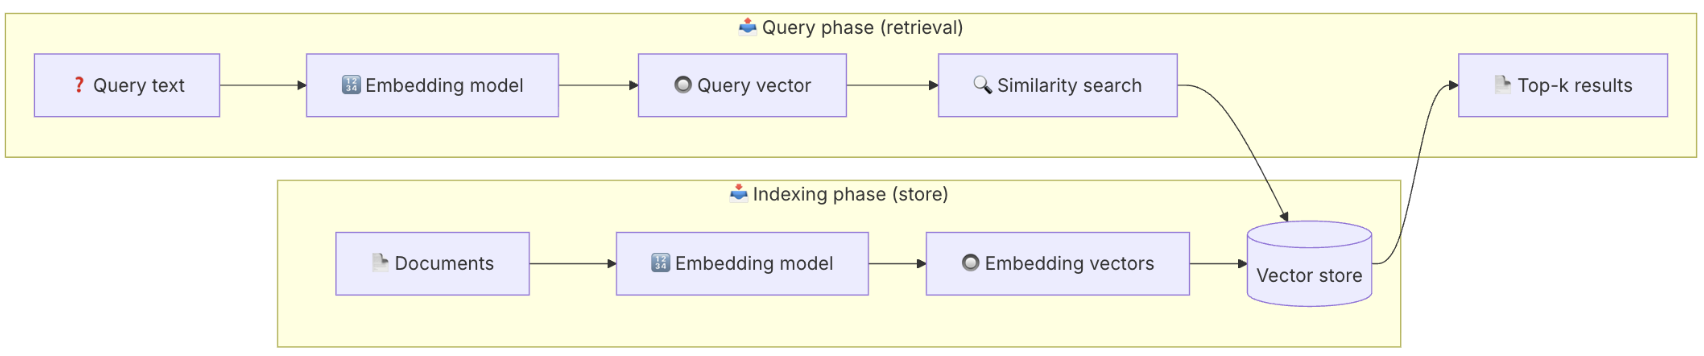

In [ ]:
# Import PDF loader to read and parse PDF files page by page
from langchain_community.document_loaders import PyPDFLoader
import os
# Import text splitter to break large documents into smaller chunks for embedding
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [ ]:
# Verify the current working directory (the PDF should be located here)
os.getcwd()

In [ ]:
# Build the full file path to the PDF document
file_path=os.path.join(os.getcwd(), "ctsarxiv.pdf")

In [ ]:
# Create a PDF loader and load the document (each page becomes a separate Document object)
loader = PyPDFLoader(file_path)
document = loader.load()
# Preview the 11th page (index 10) to inspect the loaded content
document[10]

In [ ]:
# Configure the text splitter to break documents into chunks of 1000 characters
# with 200-character overlap to preserve context across chunk boundaries
# Note: chunk_size and chunk_overlap are experimental — no deterministic best values yet
text_splitter=RecursiveCharacterTextSplitter( 
    chunk_size=1000,       # max characters per chunk
    chunk_overlap=200,     # characters shared between consecutive chunks
    length_function=len    # use Python's built-in len to measure chunk size
    )

In [ ]:
# Split the loaded PDF pages into smaller, overlapping chunks
docs = text_splitter.split_documents(document)

In [ ]:
# Inspect all the chunks produced by the text splitter
docs

In [ ]:
# Compare: number of original pages vs. number of chunks after splitting
len(document), len(docs)

In [ ]:
# Display the raw text content of the first page
document[0].page_content

## 2. CREATE EMBEDINGS

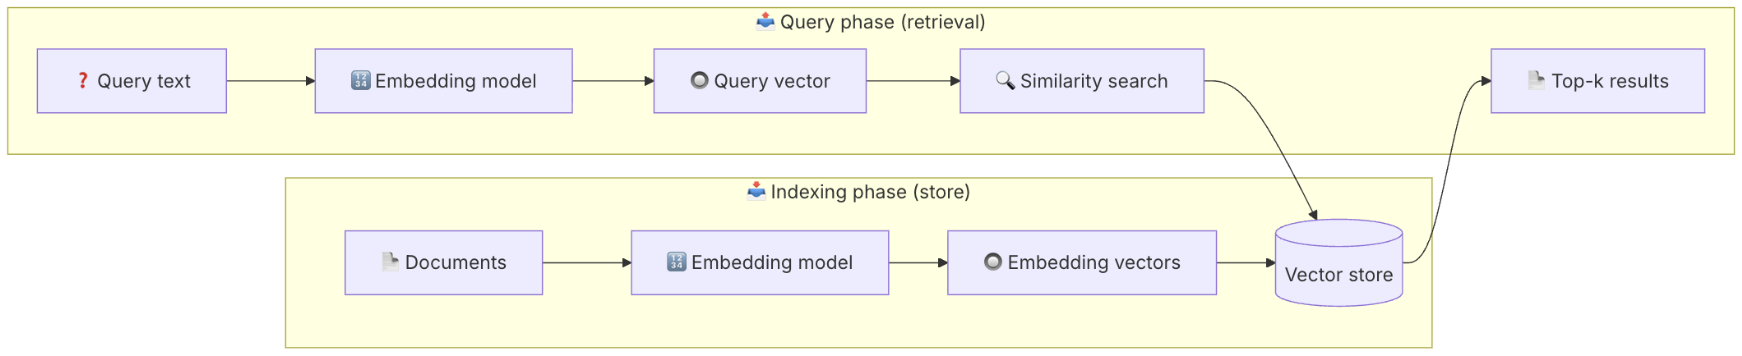

In [ ]:
# Re-initialize the LangChain embedding model for use with the vector store
from langchain_google_genai import GoogleGenerativeAIEmbeddings

embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

In [ ]:
# Generate embeddings for the first page's content to verify the model works on document text
embeddings.embed_documents([document[0].page_content])

## 3. Build a Vector Store

In [ ]:
# FAISS is a fast, in-memory vector similarity search library
from langchain_community.docstore.in_memory import InMemoryDocStore
from langchain_community.vectorstores import FAISS

# Build a FAISS vector store by embedding all document pages and indexing them
vector_store = FAISS.from_documents(
document, embeddings  # embeds each document and stores the vectors
)

## 4. Data Retrieval - Similarity Search

In [ ]:
# Perform a similarity search: find the top 8 most relevant document chunks for the query
relevant_document=vector_store.similarity_search("What is this document about?", k=8)

In [ ]:
# Display the text content of the most relevant document chunk
relevant_document[0].page_content

In [ ]:
# Convert the vector store into a LangChain retriever for use in a RAG chain
retriever=vector_store.as_retriever()

In [ ]:
# Test the retriever by querying it directly — returns the most relevant document chunks
retriever.invoke("Gemini Finetuning benchmarking experiments")

## 5. CREATE PROMPT

In [ ]:
# Define a prompt template that instructs the LLM to answer based only on retrieved context
# {context} will be filled with relevant document chunks, {question} with the user's query
prompt_template = """
Answer the question based on the context below.
If the context does not contain sufficient information, respond with: "I don't have sufficient information".
Context: {context}
Question: {question}
Answer: """

In [ ]:
# Create a LangChain PromptTemplate object from the template string
from langchain_core.prompts import PromptTemplate
prompt=PromptTemplate(
    template=prompt_template,
    input_variables=["context", "question"]  # variables that will be substituted at runtime
)

In [ ]:
# Inspect the prompt template object to verify its structure
prompt

## 6. Create RAG Chain

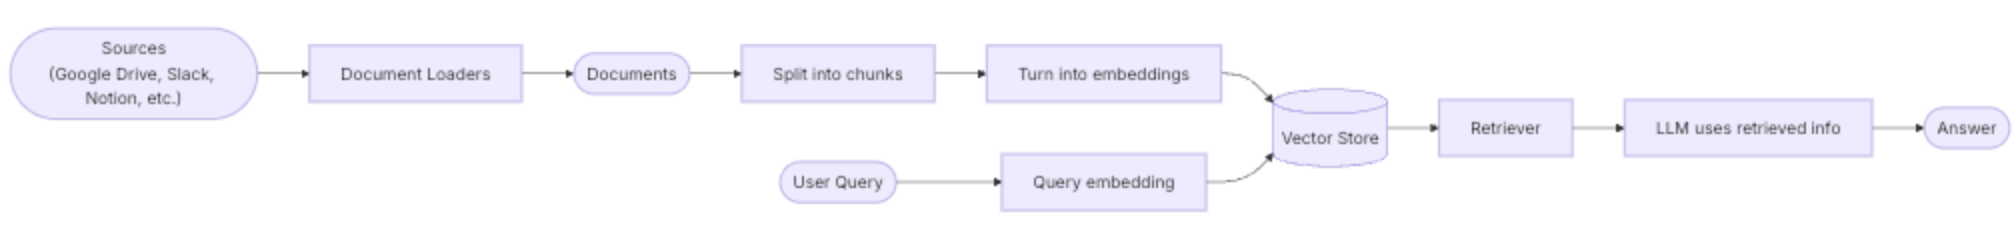

In [ ]:
# StrOutputParser converts the LLM's response object into a plain string
from langchain_core.output_parsers import StrOutputParser

In [ ]:
# RunnablePassthrough passes the input through unchanged — used to forward the question in the chain
from langchain_core.runnables import RunnablePassthrough

In [ ]:
# Instantiate the output parser to extract plain text from LLM responses
parser = StrOutputParser()

In [ ]:
# Helper function to concatenate retrieved document chunks into a single context string
def format_docs(texts):
    return "\n\n".join([doc.page_content for doc in texts])

In [ ]:
# Initialize the Gemini LLM for generating answers
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

# Build the RAG chain using LangChain Expression Language (LCEL):
# 1. Retrieve relevant docs and format them as context; pass the question through unchanged
# 2. Fill the prompt template with context + question
# 3. Send the filled prompt to the LLM
# 4. Parse the LLM output into a plain string
rag_chain = ( 
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
    )

In [ ]:
# Run the full RAG pipeline: retrieve → format → prompt → LLM → parse
rag_chain.invoke("What is Gemini Finetuning benchmarking experiments about?")